Analyses corresponding to Supplementary Figure S3

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyranges as pr
from collections import Counter
import pysam 
import seaborn as sns
from scipy import stats
import re
import pysam
import collections

In [2]:
def annotate_spliceai_effect(df: pd.DataFrame) -> pd.DataFrame:
    cols = ['SpliceAI_pred_DS_AG','SpliceAI_pred_DS_AL','SpliceAI_pred_DS_DG','SpliceAI_pred_DS_DL']
    labels = ['acceptor_gain', 'acceptor_loss','donor_gain','donor_loss']
    ds_matrix = (df[cols].apply(pd.to_numeric, errors='coerce').fillna(0).to_numpy())
    max_idx = ds_matrix.argmax(axis=1)
    max_score = ds_matrix.max(axis=1)
    # Map severity
    severity = np.select(
        [max_score >= 0.8,max_score >= 0.5,max_score >= 0.2],
        ['high','moderate','low'],
        default='none'
    )
    # Map effect
    effect = [labels[i] for i in max_idx]
    effect = np.where(max_score == 0, 'none', effect)
    df['spliceai_severity'] = severity
    df['spliceai_effect'] = effect

    return df

def categorize_hc_lof(row) -> str:
    lof_flag = str(row.get("LoF", "")).upper()
    spliceai_sev = str(row.get("spliceai_severity", "")).lower()
    if lof_flag in {"HC", "OS"} or spliceai_sev == "high":
        return "Yes"
    return np.nan

output_dir = "/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data"

LOF = {
    "stop_gained", "frameshift_variant", "stop_gained&frameshift_variant",
    "splice_acceptor_variant", "splice_donor_variant",
    "stop_gained&splice_region_variant", "frameshift_variant&splice_region_variant"
}

indel_terms = [
    "frameshift_variant",
    "frameshift_variant&splice_region_variant",
    "stop_gained&frameshift_variant",
    "stop_gained&inframe_deletion",
    "inframe_deletion",
    "inframe_insertion",
    "frameshift_variant&stop_lost",
    "frameshift_variant&start_lost",
]

non_coding_terms = [
    "intron_variant",
    "splice_polypyrimidine_tract_variant&intron_variant",
    "splice_region_variant&splice_polypyrimidine_tract_variant&intron_variant",
    "splice_donor_region_variant&intron_variant",
    "splice_region_variant&5_prime_UTR_variant",
    "splice_donor_5th_base_variant&intron_variant",
    "splice_region_variant&intron_variant",
    "3_prime_UTR_variant",
    "5_prime_UTR_variant",
    # "splice_acceptor_variant", "splice_donor_variant"
]

splice_site_terms = ["splice_acceptor_variant", "splice_donor_variant"]
missense_terms = ["missense_variant", "missense_variant&splice_region_variant"]
nonsense_terms = ["stop_gained", "stop_gained&splice_region_variant", "stop_gained&frameshift_variant", "stop_gained&inframe_deletion"]
frameshift_terms = ["frameshift_variant", "frameshift_variant&splice_region_variant", "frameshift_variant&stop_lost", "frameshift_variant&start_lost"]
synonymous_terms = ['synonymous_variant', 'stop_retained_variant', 'splice_region_variant&synonymous_variant']
nonsynonymous_terms = [
    "start_lost",
    "missense_variant",
    "frameshift_variant",
    "stop_gained",
    "missense_variant&splice_region_variant",
    "inframe_deletion",
    "frameshift_variant&splice_region_variant",
    "inframe_insertion",
    "stop_gained&splice_region_variant",
    "stop_lost",
    "stop_gained&frameshift_variant",
    "frameshift_variant&stop_lost",
    "stop_gained&inframe_deletion",
    "frameshift_variant&start_lost",
]

parquet_dir = "/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/parquets/"
AF_FILTERED = pd.read_parquet(f"{parquet_dir}AF_filtered_STG_final.parquet")
DP = pd.read_parquet(f"{parquet_dir}DP_filtered_STG_final.parquet")
metadata_filtered = pd.read_parquet(f"{parquet_dir}metadata_filtered_repeats_germline_freq.parquet")
GQ = pd.read_parquet(f"{parquet_dir}GQ_filtered_STG_final.parquet")
NGT_final = pd.read_parquet(f"{parquet_dir}NGT_filtered_STG_final.parquet")

metadata_filtered['age_at_death'] = metadata_filtered['age_at_death'].astype(str).str.replace(',', '.', regex=False)
metadata_filtered = metadata_filtered.loc[NGT_final.index]

# Load annotations
annotations = pd.read_csv('/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/Annotations_STG.csv', sep='\t', header=0) 
annotations['Protein_annotation'] = annotations['HGVSp'].str.split(".", expand=True)[2]

annotations = annotations[annotations['variant_id'].isin(NGT_final.columns)]
annotate_spliceai_effect(annotations)

genes = ["TARDBP", "TET2", "TMEM106B", "OPTN", "TBK1", "GRN", "UNC13A"]
annotations_df = []
NGT_list_filtered = []
NGT_patients_list = []
NGT_controls_list = []

ann_all_vars_list = []
ann_all_snv_list = []
ann_all_indels_list = []

ann_coding_list = []
ann_indels_list = []
ann_snv_list = []

ann_nonsyn_list = []
ann_syn_list = []
ann_missense_list = []
ann_nonsense_list = []
ann_frameshift_list = []
ann_splicesite_list = []
ann_startloss_list = []
ann_stoploss_list = []
cadd_above20_list = []
ann_LOF_list = []
ann_HC_LOF_list = []

var_groups_dict = {}
burden_dict = {}
var_groups_names = [
    "Coding_variants", "SNVs", "Indels", "Synonymous",
    "Non_synonymous", "Missense", "Nonsense",
    "Frameshift", "Splice site", "LOF", "HC_LOF", "CADD_atleast20",
]

for i, gene_name in enumerate(genes):
    print(gene_name)
    ann = annotations[annotations['SYMBOL']==gene_name].copy()
    ann.index = ann['variant_id']
    ann["HC_LOF"] = ann.apply(categorize_hc_lof,  axis=1)
    ann = ann.set_index('variant_id')

    vars = ann.index.tolist()
    NGT = NGT_final.loc[:, vars].copy()
    meta = metadata_filtered.reindex(NGT.index).copy()

    NGT = NGT.assign(
        sample_identifier = meta['ID'],
        sample_id         = meta['sample_id'],
        sample_type       = meta['sample_type'],
        age_at_death      = meta['age_at_death'].to_numpy(),
        age_at_onset      = meta['age_at_onset'].to_numpy(),
        hemisphere        = meta['hemisphere'],
    )
    NGT_list_filtered.append(NGT)
    
    NGT_controls = NGT[NGT['sample_type'] == "C"]
    NGT_patients = NGT[NGT['sample_type'] == "P"]

    counts = pd.DataFrame({
        "cell_count_patients": NGT_patients.iloc[:, :-6].isin([1, 2]).sum(),
        "total_genotyped_cells_P": NGT_patients.iloc[:, :-6].isin([0, 1, 2]).sum()
    })
    counts["mutation_freq_P"] = counts["cell_count_patients"] / counts["total_genotyped_cells_P"] * 100
    ann = ann.merge(counts, left_index=True, right_index=True, how="inner")

    counts_C = pd.DataFrame({
        "cell_count_controls": NGT_controls.iloc[:, :-6].isin([1, 2]).sum(),
        "total_genotyped_cells_C": NGT_controls.iloc[:, :-6].isin([0, 1, 2]).sum()
    })
    counts_C["mutation_freq_C"] = counts_C["cell_count_controls"] / counts_C["total_genotyped_cells_C"] * 100
    ann = ann.merge(counts_C, left_index=True, right_index=True, how="inner")
    ann["total_cells"] = ann["cell_count_patients"] + ann["cell_count_controls"]
    ann["total_genotyped_cells"] = ann['total_genotyped_cells_P'] + ann['total_genotyped_cells_C']
    ann['total_freq'] = ann["total_cells"]/ann['total_genotyped_cells']*100

    annotations_df.append(ann)
    NGT_patients_list.append(NGT_patients)
    NGT_controls_list.append(NGT_controls)

    lengths_ref = ann['REF'].apply(len)
    length_alt = ann['ALT'].apply(len)
    indels = (lengths_ref[lengths_ref >1].index.to_list()) + (length_alt[length_alt >1].index.to_list()) # Count total number of indels
    indels = list(set(indels))
    ann_all_snv = ann.drop(index = indels) # To calculate total number of SNVs
    ann_all_indels = ann.loc[indels]

    ann_coding = ann[~ann['Consequence'].isin(non_coding_terms)]
    ann_indel = ann_coding[ann_coding['Consequence'].isin(indel_terms)] #Indels in coding regions 
    ann_snv = ann_coding[~ann_coding['Consequence'].isin(indel_terms)] # SNVs in coding regions
    
    ann_nonsyn = ann_coding[ann_coding['Consequence'].isin(nonsynonymous_terms)]
    ann_syn = ann_coding[ann_coding['Consequence'].isin(synonymous_terms)]
    ann_missense = ann_coding[ann_coding['Consequence'].isin(missense_terms)]
    ann_nonsense = ann_coding[ann_coding['Consequence'].isin(nonsense_terms)]
    ann_frameshift = ann_coding[ann_coding['Consequence'].isin(frameshift_terms)]
    ann_splicesite = ann_coding[ann_coding['Consequence'].isin(splice_site_terms)]
    ann_startloss = ann_coding[ann_coding['Consequence'].isin(["start_lost"])]
    ann_stoploss = ann_coding[ann_coding['Consequence'].isin(["stop_lost"])]
    ann_lof = ann_coding[ann_coding['Consequence'].isin(list(LOF))]
    ann_lof_hf = ann_lof[ann_lof['HC_LOF']=="Yes"]
    cadd_above20 = ann_snv[ann_snv['CADD_PHRED'] >= 20]

    ann_all_vars_list.append(ann)
    ann_all_snv_list.append(ann_all_snv)
    ann_all_indels_list.append(ann_all_indels)
    ann_snv_list.append(ann_snv)
    ann_indels_list.append(ann_indel)
    ann_coding_list.append(ann_coding)
    ann_nonsyn_list.append(ann_nonsyn)
    ann_syn_list.append(ann_syn)

    ann_missense_list.append(ann_missense)
    ann_nonsense_list.append(ann_nonsense)
    ann_frameshift_list.append(ann_frameshift)
    ann_splicesite_list.append(ann_splicesite)
    ann_startloss_list.append(ann_startloss)
    ann_stoploss_list.append(ann_stoploss)
    ann_LOF_list.append(ann_lof)
    ann_HC_LOF_list.append(ann_lof_hf)
    cadd_above20_list.append(cadd_above20)

    var_groups_dict[gene_name] = {
        group_name: group_list[i]
        for group_name, group_list in zip(
            var_groups_names,
            [
                ann_coding_list,
                ann_snv_list,
                ann_indels_list,
                ann_syn_list,
                ann_nonsyn_list,
                ann_missense_list,
                ann_nonsense_list,
                ann_frameshift_list,
                ann_splicesite_list,
                ann_LOF_list,
                ann_HC_LOF_list,
                cadd_above20_list

            ]
        )
    }

    df = NGT.copy()
    ids_selected = df['sample_id'].unique()
    list_vars = var_groups_dict[gene_name]
    

/tmp/ipykernel_381797/1423658854.py:93: DtypeWarning: Columns (37,39,76) have mixed types. Specify dtype option on import or set low_memory=False.
  annotations = pd.read_csv('/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/Annotations_STG.csv', sep='\t', header=0)


TARDBP
TET2
TMEM106B
OPTN
TBK1
GRN
UNC13A


In [3]:
all_snvs = []
for i in range(len(ann_all_snv_list)):
    all_snvs.extend(ann_all_snv_list[i].index.to_list())
len(all_snvs)

27109

In [4]:
# Reverse complment a given DNA sequence
def revcomp(seq):
    tbl = str.maketrans("ACGTacgt", "TGCAtgca")
    return seq.translate(tbl)[::-1]

#Normalise the 3-mer so that the center base is a pyrimidine (C or T).
def normalize_to_pyrimidine(trimer, ref_base, alt_base):
    """Return 3-mer normalized so center base is C/T (pyrimidine-based convention)."""
    tri = trimer.upper()
    center = ref_base.upper()
    alt = alt_base.upper()
    if center in ("C", "T"):
        return tri, alt
    return revcomp(tri), revcomp(alt)

# Fetch a 3-mer centered at a given 1-based position.
def fetch_trimer(fa, chrom, pos1):
    """Fetch 3-mer centered at 1-based position pos1. Returns None if near edges or contains N."""
    start0 = pos1 - 2
    end0 = pos1 + 1
    if start0 < 0:
        return None
    seq = fa.fetch(chrom, start0, end0)
    return seq if len(seq) == 3 and "N" not in seq.upper() else None

# Parse a variant ID in the format "chr#:pos:REF/ALT"
def parse_variant_id(vid):
    chrom, pos, refalt = vid.split(":")
    ref, alt = refalt.split("/")
    return chrom, int(pos), ref.upper(), alt.upper()

def load_gene_intervals_from_gtf(gtf_path):
    gr = pr.read_gtf(gtf_path)
    genes = gr[gr.Feature == "gene"].df[["Chromosome","Start","End","Strand","gene_id","gene_name"]].copy()
    genes = genes.rename(columns={"gene_id":"GeneID","gene_name":"GeneName"})
    return pr.PyRanges(genes)


def variants_from_columns(df_cols):
    """Parse df column headers into a tidy variant table."""
    recs = []
    for vid in df_cols:
        parsed = parse_variant_id(vid)
        if not parsed:
            continue  # skip non-variant columns
        chrom, pos, ref, alt = parsed
        if (len(alt) == 1) & (len(ref) == 1):
            recs.append({"variant_id": vid, "Chromosome": chrom, "Pos": pos, "REF": ref, "ALT": alt})
    return pd.DataFrame(recs)


# --------------------
# Build observed context histogram from DF columns
# --------------------
def observed_contexts_from_df(df, fa, gtf_path):
    """
    From a matrix (columns = 'chr:pos:REF/ALT'), build a per-variant table with:
      - normalized 96-context (Context)
      - normalized 3-mer (Tri)
      - substitution in normalized frame (Substitution)
      - gene overlap + strand, template/non-template labels
    """
    variant_ids = df.columns.to_list()
    fasta = pysam.FastaFile(fa)

    records = []
    for vid in variant_ids:
        parsed = parse_variant_id(vid)
        if not parsed:
            continue  # skip non-variant columns
        chrom, pos, ref, alt = parsed
        # keep SNVs only
        if not (len(ref) == 1 and len(alt) == 1):
            continue
        tri = fetch_trimer(fasta, chrom, pos)
        if not tri:
            continue
        # normalize to pyrimidine-centered frame
        tri_norm, alt_norm = normalize_to_pyrimidine(tri, ref, alt)   # returns (tri, alt) after possible revcomp
        sub = ref + ">" + alt
        sub_norm = f"{tri_norm[1]}>{alt_norm}"                             # e.g., C>T or T>C
        context = f"{tri_norm[0]}[{sub_norm}]{tri_norm[2]}"                # e.g., G[C>T]A

        # 0-based, 1-bp interval for PyRanges
        start = pos - 1
        end   = pos

        records.append((vid, chrom, pos, start, end, ref, alt, sub, sub_norm, context, tri_norm))

    var_df = pd.DataFrame(
        records,
        columns=["variant_id","Chromosome","Pos","Start","End",
                 "REF","ALT","Substitution", "Sub_norm", "Context","Tri"]
    )

    # Build PyRanges for variants
    prv = pr.PyRanges(var_df[["Chromosome","Start","End","variant_id","REF","ALT"]])

    # Gene intervals with strand (from GTF)
    prg = load_gene_intervals_from_gtf(gtf_path)

    joined = prv.join(prg).as_df()
    if joined.empty:
        out = var_df.copy()
        out["GeneID"] = np.nan
        out["GeneName"] = np.nan
        out["gene_strand"] = np.nan
    else:
        # Remove variants overlapping genes on both strands — strand assignment is ambiguous
        strand_per_variant = joined.groupby("variant_id")["Strand"].nunique()
        ambiguous = strand_per_variant[strand_per_variant > 1].index
        joined = joined[~joined["variant_id"].isin(ambiguous)]

        joined = (joined.sort_values(["variant_id"])
                        .drop_duplicates("variant_id", keep="first"))
        out = var_df.merge(
            joined[["variant_id","GeneID","GeneName","Strand"]],
            on="variant_id", how="left"
        ).rename(columns={"Strand":"gene_strand"})
    
    return out

In [5]:
# --------------------
# Inputs
# --------------------
FASTA_PATH = "/complgen/refseq/hg38/genome_hg38.fa"
BED_PATH   = "/home/vanshika/study232-missionbio_TDP-C/design/hg38/3791_hg38.bed"
GTF_PATH = "/home/AD/vbidhan/gencode.v38.annotation.gtf"

df = NGT_final[all_snvs].copy() 
observed_contexts = observed_contexts_from_df(df, FASTA_PATH, GTF_PATH)

In [6]:
observed_contexts

,variant_id,Chromosome,Pos,Start,End,REF,ALT,Substitution,Sub_norm,Context,Tri,GeneID,GeneName,gene_strand
0,chr1:11013728:A/G,chr1,11013728,11013727,11013728,A,G,A>G,T>C,A[T>C]C,ATC,ENSG00000120948.19,TARDBP,+
1,chr1:11013728:A/T,chr1,11013728,11013727,11013728,A,T,A>T,T>A,A[T>A]C,ATC,ENSG00000120948.19,TARDBP,+
2,chr1:11013729:T/A,chr1,11013729,11013728,11013729,T,A,T>A,T>A,A[T>A]G,ATG,ENSG00000120948.19,TARDBP,+
3,chr1:11013729:T/C,chr1,11013729,11013728,11013729,T,C,T>C,T>C,A[T>C]G,ATG,ENSG00000120948.19,TARDBP,+
4,chr1:11013729:T/G,chr1,11013729,11013728,11013729,T,G,T>G,T>G,A[T>G]G,ATG,ENSG00000120948.19,TARDBP,+
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27104,chr19:17676039:T/A,chr19,17676039,17676038,17676039,T,A,T>A,T>A,T[T>A]G,TTG,ENSG00000130477.16,UNC13A,-
27105,chr19:17676039:T/C,chr19,17676039,17676038,17676039,T,C,T>C,T>C,T[T>C]G,TTG,ENSG00000130477.16,UNC13A,-
27106,chr19:17676040:G/A,chr19,17676040,17676039,17676040,G,A,G>A,C>T,T[C>T]A,TCA,ENSG00000130477.16,UNC13A,-
27107,chr19:17676041:A/G,chr19,17676041,17676040,17676041,A,G,A>G,T>C,G[T>C]C,GTC,ENSG00000130477.16,UNC13A,-


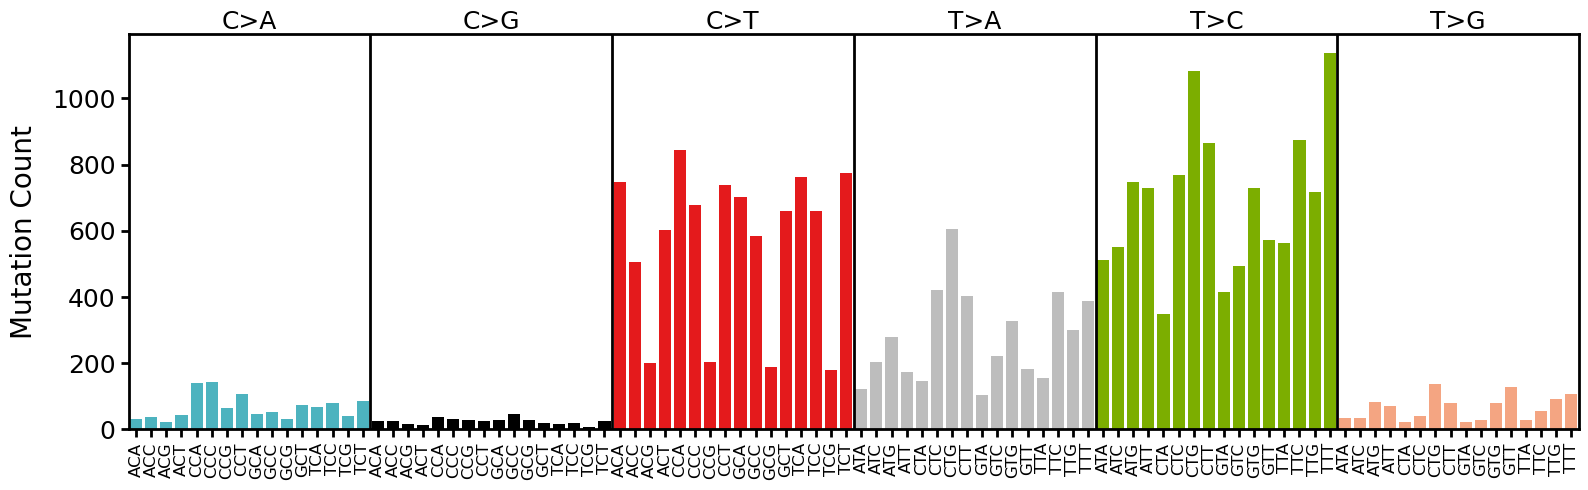

In [ ]:
df = observed_contexts.copy()

bad = ~df["Context"].str.match(r"^[ACGT]\[[CT]>[ACGT]\][ACGT]$")
if bad.any():
    raise ValueError(f"Bad context strings: {df['context'][bad].head().tolist()}")

# Counts per 96-context, also mapping to tri
counts = df.groupby(["Context", "Tri"]).size().reset_index(name="n")

# If multiple tris per context (shouldn't happen), aggregate counts
counts = counts.groupby("Context").agg({"n": "sum", "Tri": "first"}).reset_index()

# COSMIC ordering
bases = ["A","C","G","T"]
subs_order = ["C>A","C>G","C>T","T>A","T>C","T>G"]

def labels_for_sub(sub):
    return [f"{l}[{sub}]{r}" for l in bases for r in bases]

ordered_contexts = [lab for s in subs_order for lab in labels_for_sub(s)]
full = pd.DataFrame({"Context": ordered_contexts})

counts_full = full.merge(counts, on="Context", how="left").fillna({"n": 0, "Tri": ""})
counts_full["sub"] = counts_full["Context"].str.extract(r"\[([CT]>\w)\]")

colors = {
    "C>A": "#4DB3BF",
    "C>G": "#000000",
    "C>T": "#E41A1C",
    "T>A": "#BDBDBD",
    "T>C": "#7CAE00",
    "T>G": "#F4A582",
}

x = np.arange(len(ordered_contexts))
y = counts_full["n"].to_numpy()
bar_colors = [colors[s] for s in counts_full["sub"]]
xtick_labels = counts_full["Tri"].to_numpy()  # use tri values for x-axis

plt.figure(figsize=(16, 5))
plt.bar(x, y, width=0.8, color=bar_colors, edgecolor="none")

for g in range(1, 6):
    plt.axvline(g*16 - 0.5, color="k", linewidth=2)

ymax = y.max() if y.size else 1
for i, s in enumerate(subs_order):
    xmid = i*16 + 7.5
    plt.text(xmid, ymax*1.05, s, ha="center", va="bottom", fontsize=18)

plt.gca().spines['left'].set_linewidth(2)
plt.gca().spines['bottom'].set_linewidth(2)
plt.gca().spines['right'].set_linewidth(2)
plt.gca().spines['top'].set_linewidth(2)
plt.xticks(x, xtick_labels, rotation=90, fontsize=12)
plt.yticks(fontsize=18)
plt.tick_params(axis='both', width=2, length = 6)
plt.xlim(-0.5, len(ordered_contexts)-0.5)
plt.ylabel("Mutation Count", fontsize = 20, labelpad = 10)
plt.tight_layout()

plt.savefig("/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/figures/supplementary/Mutational_Plots/mutational_plot1.svg", bbox_inches="tight", transparent=True)
plt.savefig("/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/figures/supplementary/Mutational_Plots/mutational_plot1.png", dpi=600, bbox_inches="tight", transparent=True)

plt.show()

In [8]:
Counter(df["Substitution"])

Counter({'A>G': 5690,
         'T>C': 5419,
         'G>A': 4599,
         'C>T': 4440,
         'A>T': 2291,
         'T>A': 2157,
         'A>C': 593,
         'G>T': 589,
         'C>A': 484,
         'T>G': 451,
         'G>C': 219,
         'C>G': 177})

Correct for amplicon Bias

In [9]:
# Reverse complement
def revcomp(seq: str) -> str:
    tbl = str.maketrans("ACGTacgt", "TGCAtgca")
    return seq.translate(tbl)[::-1]

# Canonicalize so center is a pyrimidine (C/T)
def normalize_to_pyrimidine(trimer: str) -> str:
    tri = trimer.upper()
    return tri if tri[1] in ("C", "T") else revcomp(tri)

# Count pyrimidine-centered tri opportunities inside a BED territory
def count_trinuc_opportunities_from_bed(bed_path: str, fasta_path: str) -> pd.DataFrame:
    fa = pysam.FastaFile(fasta_path)
    opp = collections.Counter()

    with open(bed_path) as f:
        for line in f:
            if not line.strip() or line.startswith(("track", "browser", "#")):
                continue
            chrom, start_s, end_s, *rest = line.rstrip("\n").split("\t")
            start, end = int(start_s), int(end_s)
            if end - start < 3:
                continue
            fetch_start = max(0, start - 1)  # allow left neighbor
            fetch_end   = end + 1            # allow right neighbor
            seq = fa.fetch(chrom, fetch_start, fetch_end).upper()
            # # valid 3-mers that keep the center inside [start, end) ##WRONG
            # s_min = start - fetch_start
            # s_max = end - fetch_start - 3
            # Correct — center must satisfy: start <= genome_center < end
            s_min = start - fetch_start - 1  # = 0
            s_max = end - fetch_start - 2
            for s in range(s_min, s_max + 1):
                tri = seq[s:s+3]
                if len(tri) < 3 or "N" in tri:
                    continue
                opp[normalize_to_pyrimidine(tri)] += 1
                # if "N" in tri:
                #     continue
                # tri_norm = normalize_to_pyrimidine(tri)
                # opp[tri_norm] += 1

    return pd.DataFrame({"Tri": list(opp.keys()), "opportunities": list(opp.values())})



In [10]:
# Validate context strings (fixing your key to "Context")
bad = ~df["Context"].str.match(r"^[ACGT]\[[CT]>[ACGT]\][ACGT]$")
if bad.any():
    raise ValueError(f"Bad context strings: {df.loc[bad, 'Context'].head().tolist()}")

# Observed counts per 96-context (Context uniquely implies Tri, but we recompute Tri for zero-count contexts too)
counts = df.groupby("Context").size().reset_index(name="n")

# COSMIC ordering skeleton
bases = ["A","C","G","T"]
subs_order = ["C>A","C>G","C>T","T>A","T>C","T>G"]
def labels_for_sub(sub): return [f"{l}[{sub}]{r}" for l in bases for r in bases]
ordered_contexts = [lab for s in subs_order for lab in labels_for_sub(s)]
full = pd.DataFrame({"Context": ordered_contexts})

# Fill missing contexts with zero and attach Tri parsed from Context
counts_full = full.merge(counts, on="Context", how="left").fillna({"n": 0})
tri_parsed = counts_full["Context"].str.extract(r"^([ACGT])\[([CT])>[ACGT]\]([ACGT])$")
counts_full["Tri"] = tri_parsed[0] + tri_parsed[1] + tri_parsed[2]
counts_full["sub"] = counts_full["Context"].str.extract(r"\[([CT]>\w)\]")

# --- Normalize by opportunities from BED ---
tri_opps = count_trinuc_opportunities_from_bed(BED_PATH, FASTA_PATH)  # Tri, opportunities
counts_full = counts_full.merge(tri_opps, on="Tri", how="left").fillna({"opportunities": 0})

# rate = mutations per million opportunities (avoid div-by-zero)
scale = 1e6
opp = counts_full["opportunities"].to_numpy()
n   = counts_full["n"].to_numpy()
with np.errstate(divide="ignore", invalid="ignore"):
    rate = np.where(opp > 0, n / opp * scale, 0.0)
counts_full["rate_per_Mopps"] = rate


In [11]:
counts_full.sort_values(by="opportunities", ascending=False)

,Context,n,Tri,sub,opportunities,rate_per_Mopps
95,T[T>G]T,108,TTT,T>G,2461,43884.599756
79,T[T>C]T,1138,TTT,T>C,2461,462413.652987
63,T[T>A]T,387,TTT,T>A,2461,157253.149126
70,C[T>C]G,1082,CTG,T>C,1988,544265.593561
86,C[T>G]G,136,CTG,T>G,1988,68410.462777
...,...,...,...,...,...,...
42,G[C>T]G,189,GCG,C>T,311,607717.041801
10,G[C>A]G,33,GCG,C>A,311,106109.324759
14,T[C>A]G,40,TCG,C>A,290,137931.034483
46,T[C>T]G,181,TCG,C>T,290,624137.931034


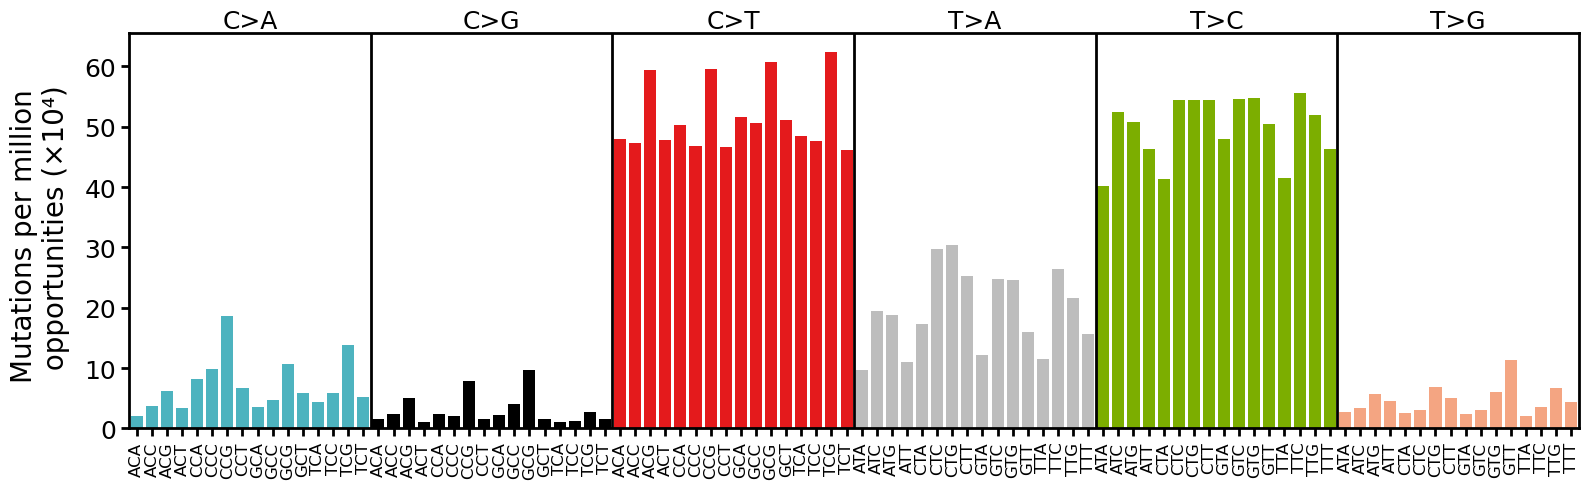

In [ ]:
x = np.arange(len(ordered_contexts))
y = counts_full["rate_per_Mopps"].to_numpy()
bar_colors = [colors[s] for s in counts_full["sub"]]
xtick_labels = counts_full["Tri"].to_numpy()

plt.figure(figsize=(16, 5))
plt.bar(x, y, width=0.8, color=bar_colors, edgecolor="none")

# vertical separators every 16 bars
for g in range(1, 6):
    plt.axvline(g*16 - 0.5, color="k",linewidth=2)

# group headings
ymax = y.max() if y.size else 1
for i, s in enumerate(subs_order):
    plt.text(i*16 + 7.5, ymax*1.05, s, ha="center", va="bottom", fontsize=18)

plt.gca().spines['left'].set_linewidth(2)
plt.gca().spines['bottom'].set_linewidth(2)
plt.gca().spines['right'].set_linewidth(2)
plt.gca().spines['top'].set_linewidth(2)

plt.xticks(x, xtick_labels, rotation=90, fontsize=12)
plt.yticks(fontsize=18)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e4:.0f}'))
plt.ylabel("Mutations per million \n opportunities (×10⁴)", fontsize=20, labelpad=10)
plt.tick_params(axis='both', width=2, length = 6)
plt.xlim(-0.5, len(ordered_contexts)-0.5)
plt.tight_layout()

plt.savefig("/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/figures/supplementary/Mutational_Plots/mutational_plot2.svg", bbox_inches="tight", transparent=True)
plt.savefig("/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/figures/supplementary/Mutational_Plots/mutational_plot2.png", dpi=600, bbox_inches="tight", transparent=True)

plt.show()


In [13]:
cpg_contexts = [c for c in counts_full['Context'] if 'C>T' in c and c[-1] == 'G']
cpg_rate  = counts_full[counts_full['Context'].isin(cpg_contexts)]['rate_per_Mopps'].mean()
non_cpg_rate = counts_full[
    counts_full['Context'].str.contains('C>T') & 
    ~counts_full['Context'].isin(cpg_contexts)
]['rate_per_Mopps'].mean()

print(f'Mean C>T rate at CpG contexts:     {cpg_rate:.0f}')
print(f'Mean C>T rate at non-CpG contexts: {non_cpg_rate:.0f}')
print(f'CpG enrichment ratio: {cpg_rate/non_cpg_rate:.2f}x')

Mean C>T rate at CpG contexts:     605616
Mean C>T rate at non-CpG contexts: 485244
CpG enrichment ratio: 1.25x


In [14]:
# Get raw counts and opportunities for CpG vs non-CpG C>T contexts
cpg_mask    = counts_full['Context'].str.contains('C>T') & (counts_full['Context'].str[-1] == 'G')
noncpg_mask = counts_full['Context'].str.contains('C>T') & (counts_full['Context'].str[-1] != 'G')

n_cpg    = counts_full.loc[cpg_mask,    'n'].sum()
n_noncpg = counts_full.loc[noncpg_mask, 'n'].sum()
o_cpg    = counts_full.loc[cpg_mask,    'opportunities'].sum()
o_noncpg = counts_full.loc[noncpg_mask, 'opportunities'].sum()

# Rate ratio and 95% CI via Poisson exact test
rate_ratio = (n_cpg / o_cpg) / (n_noncpg / o_noncpg)

# Confidence interval on the rate ratio
result = stats.poisson_means_test(n_cpg, o_cpg, n_noncpg, o_noncpg)

print(f"CpG C>T count:     {n_cpg}")
print(f"non-CpG C>T count: {n_noncpg}")
print(f"Rate ratio:        {rate_ratio:.3f}")
print(f"p-value:           {result.pvalue:.2e}")

# Rate ratio CI via log-normal approximation (standard for Poisson rate ratios)
log_rr = np.log(rate_ratio)
se_log_rr = np.sqrt(1/n_cpg + 1/n_noncpg)

ci_low  = np.exp(log_rr - 1.96 * se_log_rr)
ci_high = np.exp(log_rr + 1.96 * se_log_rr)

print(f"95% CI:     {ci_low:.3f} – {ci_high:.3f}")

CpG C>T count:     776
non-CpG C>T count: 8263
Rate ratio:        1.248
p-value:           2.42e-07
95% CI:     1.160 – 1.343


In [15]:
# Classify each C>T context by 3' base
ct = counts_full[counts_full['Context'].str.contains('C>T')].copy()
ct['right'] = ct['Context'].str[-1]

summary = (ct.groupby('right')
             .agg(n=('n','sum'), opp=('opportunities','sum'))
             .assign(rate=lambda x: x['n']/x['opp']*1e6))

# Rate ratio relative to mean of non-CpG (non-G) contexts
baseline = summary.loc[summary.index != 'G', 'rate'].mean()
summary['rate_ratio_vs_nonCpG'] = summary['rate'] / baseline

print(summary[['n','opp','rate','rate_ratio_vs_nonCpG']].round(2))

          n   opp       rate  rate_ratio_vs_nonCpG
right                                             
A      3058  6176  495142.49                  1.02
C      2429  5060  480039.53                  0.99
G       776  1283  604832.42                  1.25
T      2776  5815  477386.07                  0.99
